# Module 11 — Cell-Cell Communication Analysis (v4)

This notebook visualizes pre-computed cell-cell communication (CCC) results
from `scripts/11_communication.py`. LIANA (LIgand-receptor ANAlysis) is used
to infer ligand-receptor interactions between cell types, comparing healthy
and degenerated IVD tissue.

**Pipeline version:** v4 (scANVI-based, 12 modules)

**Data sources:**
- `results/communication/interactions_healthy.tsv` — Healthy interactions
- `results/communication/interactions_degenerated.tsv` — Degenerated interactions
- `results/communication/differential_interactions.tsv` — Differential analysis
- `results/communication/pain_interactions.tsv` — Pain-relevant interactions
- `results/communication/interaction_plots/` — Visualization plots

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
RESULTS = BASE / 'results' / 'communication'
PLOT_DIR = RESULTS / 'interaction_plots'

print(f'Results directory: {RESULTS}')
print(f'Plot files:       {len(list(PLOT_DIR.glob("*.png")))} files')

Results directory: /home/ubuntu/lotz-ivd/results/communication
Plot files:       5 files


## Interaction Counts Summary

Overview of the number of inferred ligand-receptor interactions in healthy
vs degenerated tissue.

In [2]:
# Load interaction tables
healthy_path = RESULTS / 'interactions_healthy.tsv'
degen_path = RESULTS / 'interactions_degenerated.tsv'

if healthy_path.exists() and degen_path.exists():
    healthy = pd.read_csv(healthy_path, sep='\t')
    degen = pd.read_csv(degen_path, sep='\t')
    
    print(f'Healthy interactions:     {len(healthy):,}')
    print(f'Degenerated interactions: {len(degen):,}')
    print(f'Difference:              {len(degen) - len(healthy):+,}')
    print()
    
    # Unique source-target pairs
    if 'source' in healthy.columns and 'target' in healthy.columns:
        h_pairs = healthy.groupby(['source', 'target']).size()
        d_pairs = degen.groupby(['source', 'target']).size()
        print(f'Unique source-target pairs (healthy):     {len(h_pairs)}')
        print(f'Unique source-target pairs (degenerated): {len(d_pairs)}')
    
    # Preview
    cols = [c for c in ['source', 'target', 'ligand_complex', 'receptor_complex',
                        'lr_means', 'lrscore'] if c in healthy.columns]
    display(Markdown('**Top Healthy Interactions (by score)**'))
    display(healthy.nlargest(10, 'lrscore' if 'lrscore' in healthy.columns else cols[-1])[cols])
else:
    print('Interaction files not found')

Healthy interactions:     39,236
Degenerated interactions: 37,013
Difference:              -2,223

Unique source-target pairs (healthy):     169
Unique source-target pairs (degenerated): 169


**Top Healthy Interactions (by score)**

,source,target,ligand_complex,receptor_complex,lr_means,lrscore
0,NP_fibrocartilaginous,NP_fibrocartilaginous,TIMP1,CD63,2.670295,0.907290
1,EP_hyaline,NP_fibrocartilaginous,TIMP1,CD63,2.625538,0.905791
2,NP_fibrocartilaginous,AF_outer,TIMP1,CD63,2.600307,0.905084
3,AF_inner,NP_fibrocartilaginous,TIMP1,CD63,2.600422,0.904915
4,AF_outer,NP_fibrocartilaginous,TIMP1,CD63,2.573467,0.903947
5,EP_hyaline,AF_outer,TIMP1,CD63,2.555549,0.903553
6,NP_fibrocartilaginous,NP_stressed,TIMP1,CD63,2.536306,0.902917
7,AF_inner,AF_outer,TIMP1,CD63,2.530434,0.902659
8,NP_fibrocartilaginous,AF_inner,TIMP1,CD63,2.525784,0.902546
9,NP_fibrocartilaginous,Fibroblast_like,TIMP1,CD63,2.512500,0.902071


## Interaction Heatmaps

Heatmaps showing the number/strength of interactions between each pair of
cell types, separately for healthy and degenerated conditions.

### Healthy — Cell-Cell Interaction Heatmap

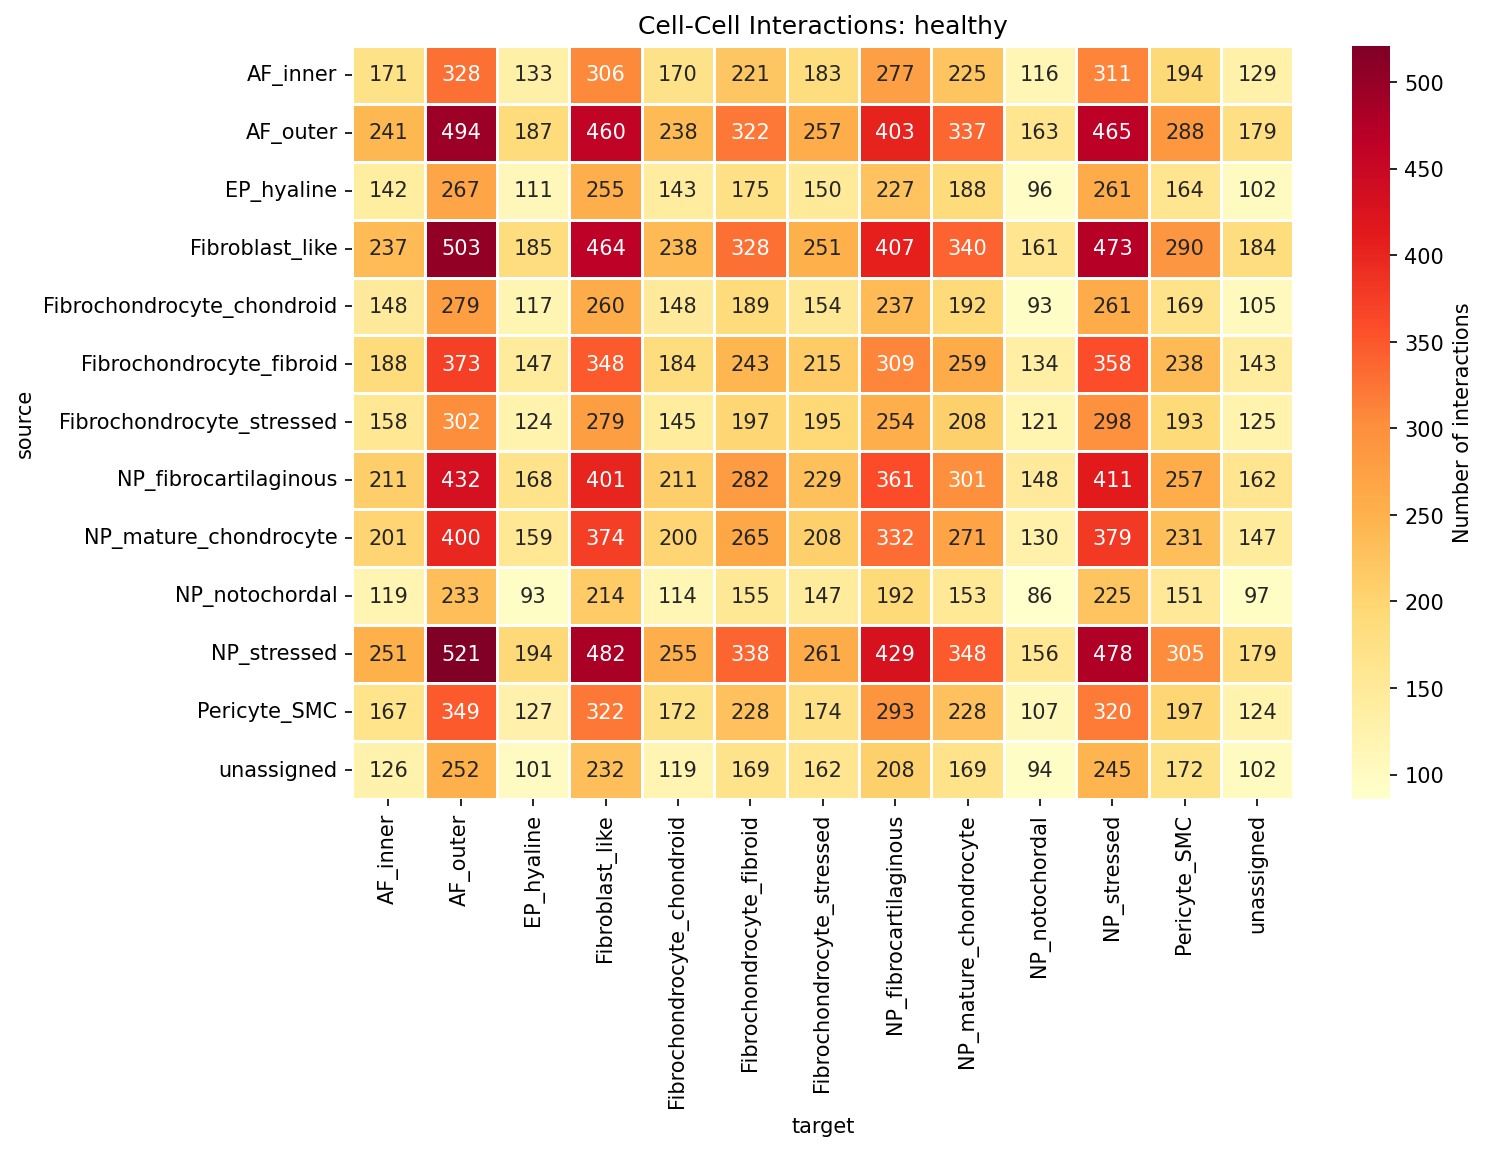

In [3]:
# Healthy interaction heatmap
h_heatmap = PLOT_DIR / 'interaction_heatmap_healthy.png'
if h_heatmap.exists():
    display(Markdown('### Healthy — Cell-Cell Interaction Heatmap'))
    display(Image(filename=str(h_heatmap), width=800))
else:
    print('Healthy interaction heatmap not found')

### Degenerated — Cell-Cell Interaction Heatmap

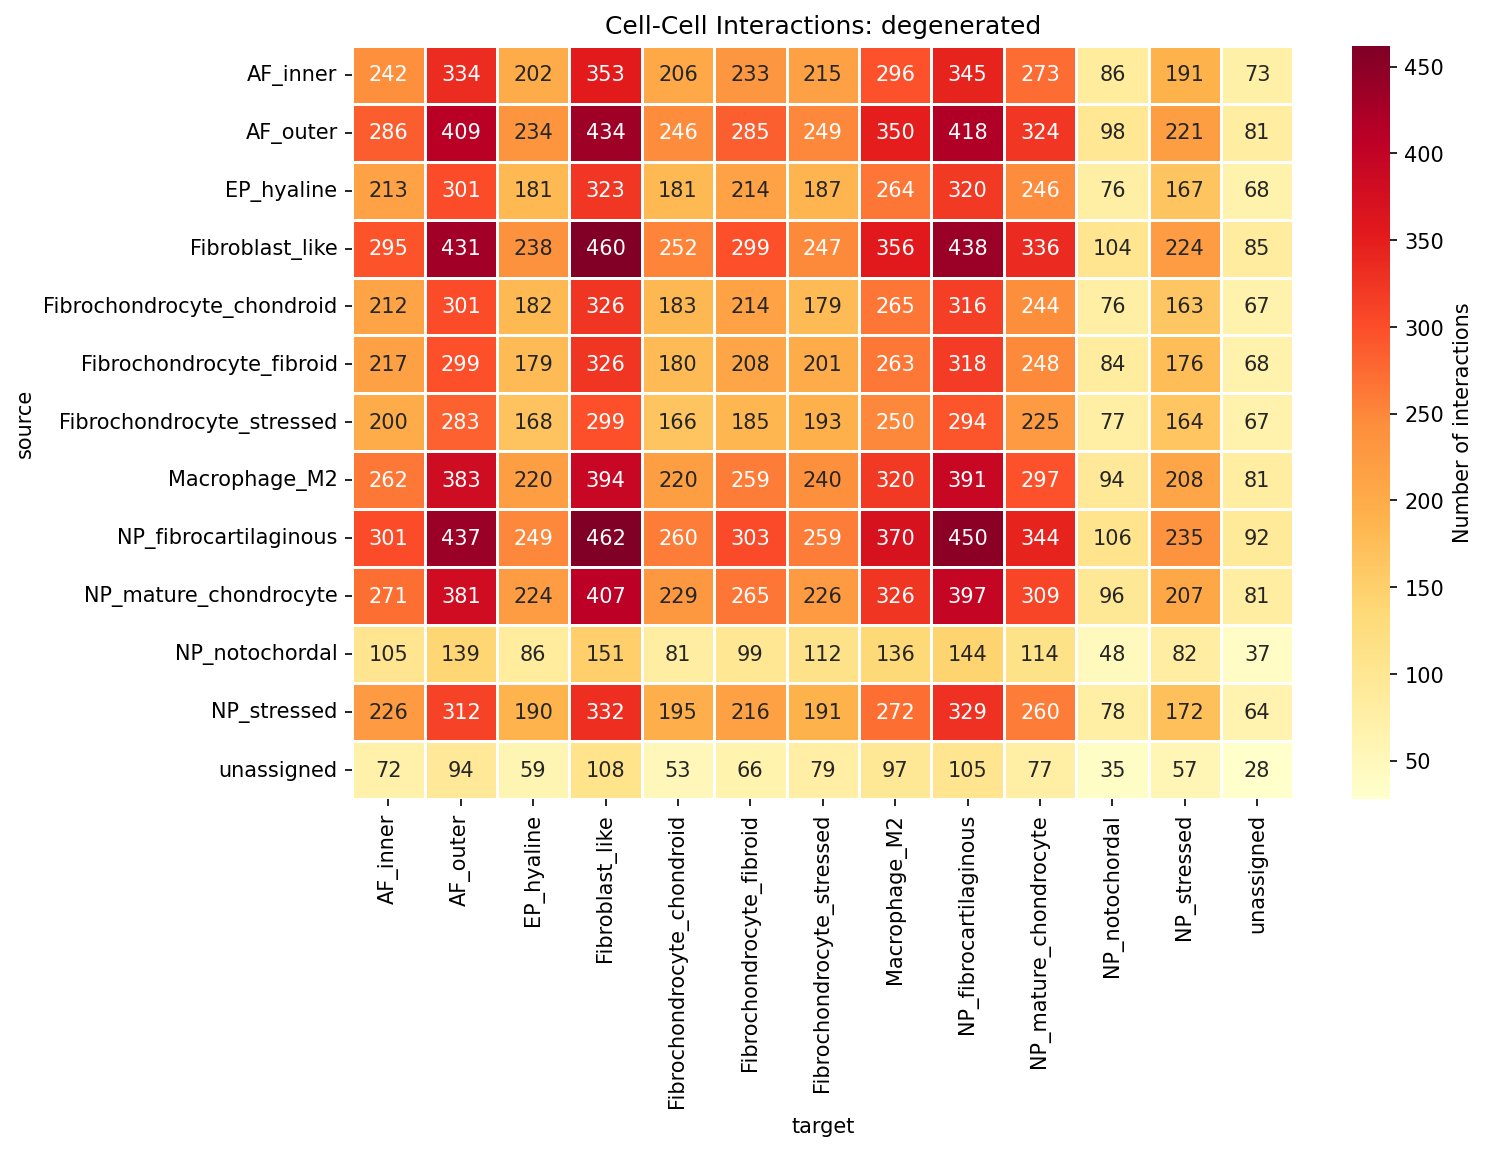

In [4]:
# Degenerated interaction heatmap
d_heatmap = PLOT_DIR / 'interaction_heatmap_degenerated.png'
if d_heatmap.exists():
    display(Markdown('### Degenerated — Cell-Cell Interaction Heatmap'))
    display(Image(filename=str(d_heatmap), width=800))
else:
    print('Degenerated interaction heatmap not found')

## Top Interactions by Condition

The highest-scoring ligand-receptor interactions in each condition.

### Top Interactions — Healthy

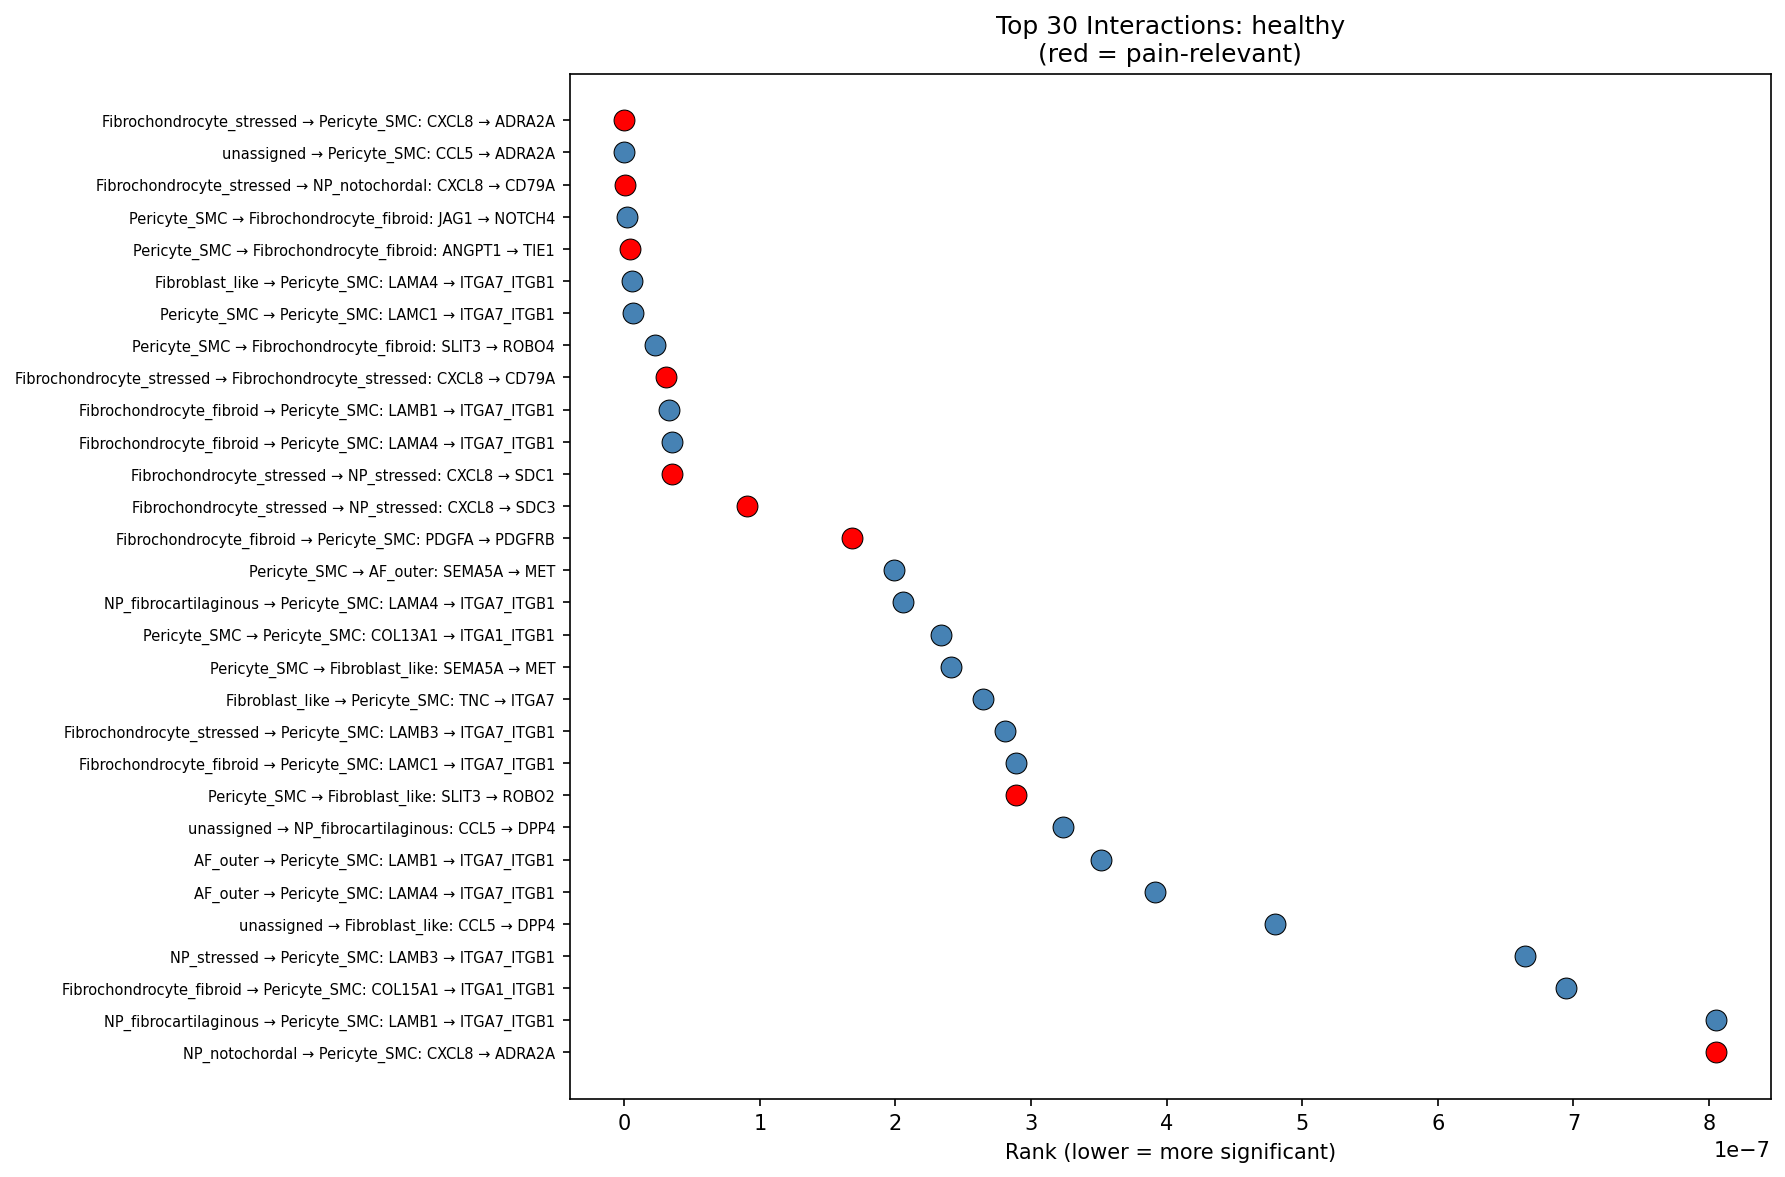

### Top Interactions — Degenerated

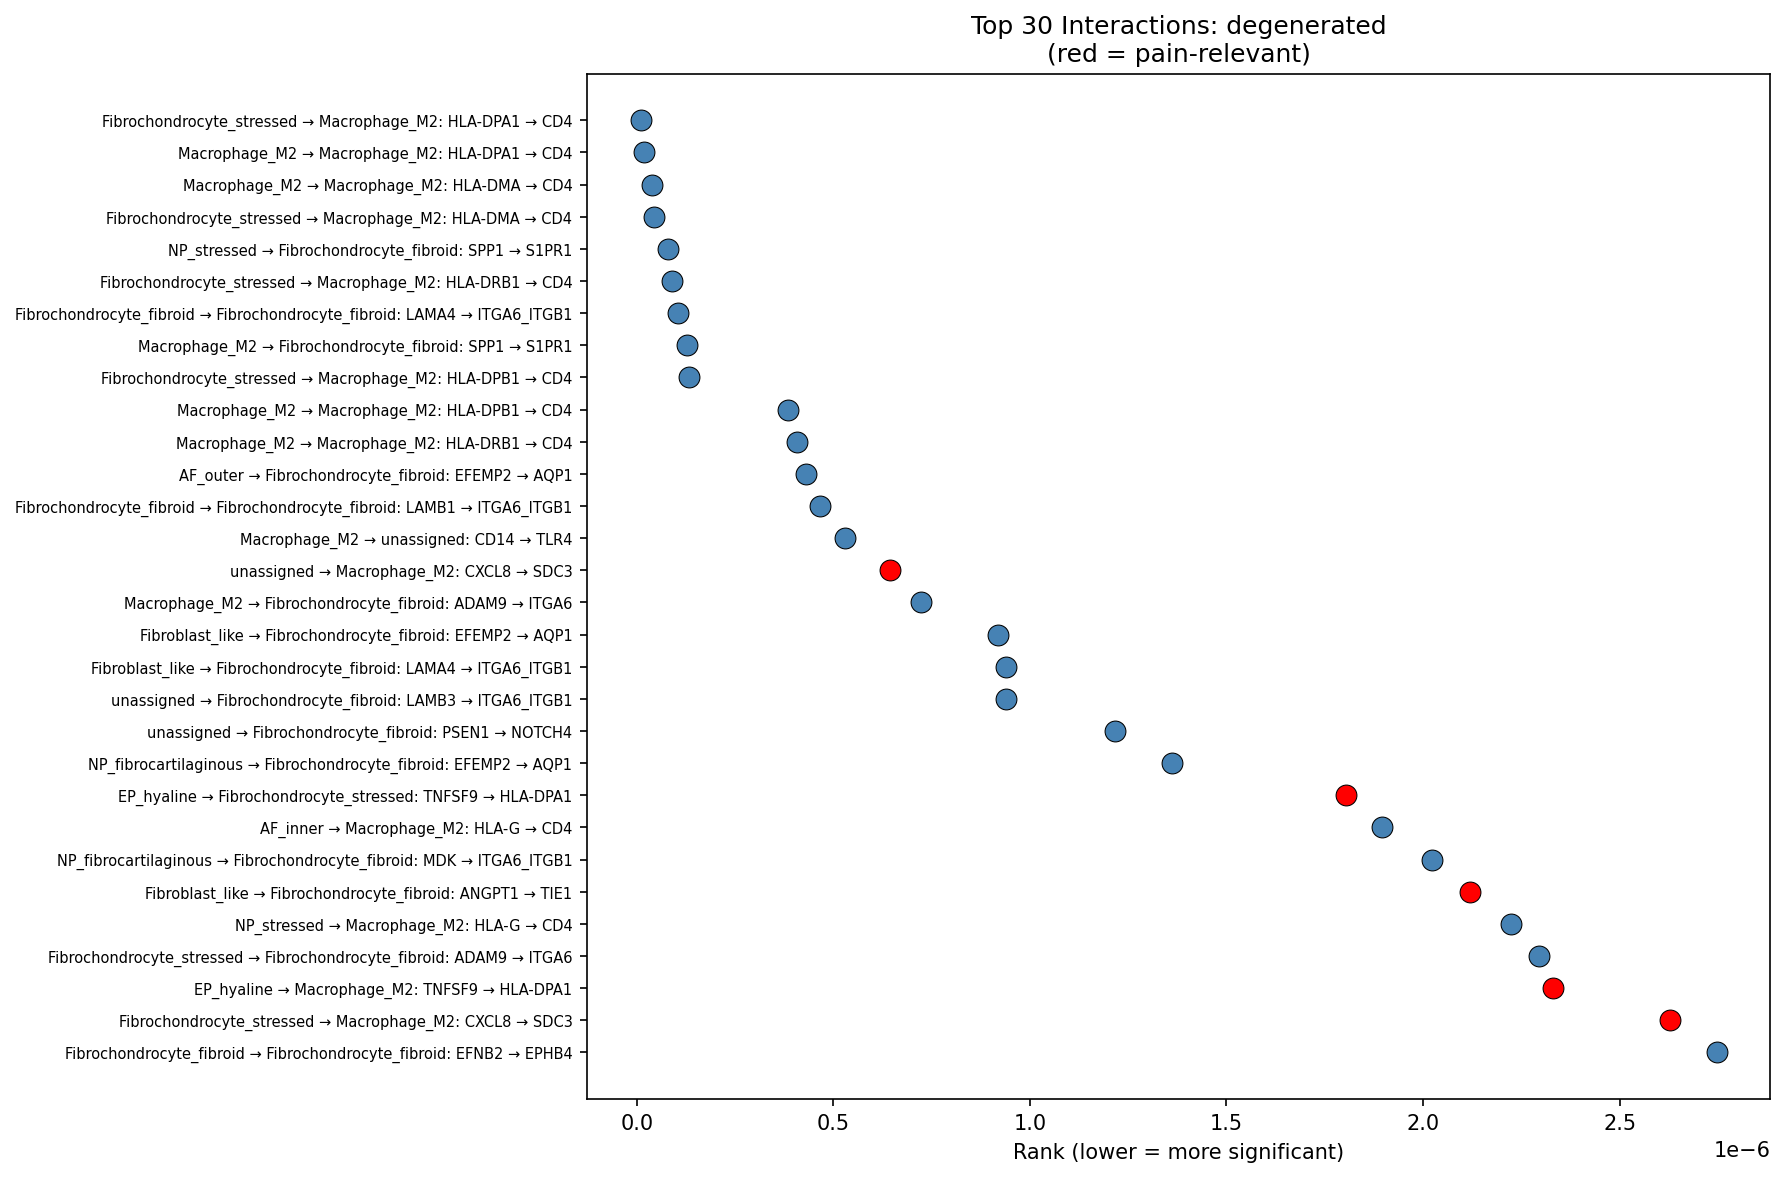

In [5]:
# Top interactions plots
for condition in ['healthy', 'degenerated']:
    top_path = PLOT_DIR / f'top_interactions_{condition}.png'
    if top_path.exists():
        display(Markdown(f'### Top Interactions — {condition.capitalize()}'))
        display(Image(filename=str(top_path), width=800))
    else:
        print(f'Top interactions plot not found for {condition}')

## Differential Interactions

Interactions that differ significantly between healthy and degenerated
conditions. Positive log fold change indicates stronger signaling in
degeneration; negative indicates loss of signaling.

In [6]:
# Differential interactions table
diff_path = RESULTS / 'differential_interactions.tsv'
if diff_path.exists():
    diff = pd.read_csv(diff_path, sep='\t')
    print(f'Total differential interactions: {len(diff)}')
    
    # Show top gained and lost interactions
    if 'lr_logfc' in diff.columns:
        gained = diff.nlargest(15, 'lr_logfc')
        lost = diff.nsmallest(15, 'lr_logfc')
        cols = [c for c in ['source', 'target', 'ligand_complex', 'receptor_complex',
                            'lr_logfc', 'lr_means'] if c in diff.columns]
        display(Markdown('**Top 15 Gained in Degeneration (highest logFC)**'))
        display(gained[cols])
        display(Markdown('**Top 15 Lost in Degeneration (lowest logFC)**'))
        display(lost[cols])
    else:
        display(diff.head(20))
else:
    print('Differential interactions file not found')

Total differential interactions: 52150


/tmp/ipykernel_19898/1873188071.py:4: DtypeWarning: Columns (14,31) have mixed types. Specify dtype option on import or set low_memory=False.
  diff = pd.read_csv(diff_path, sep='\t')


,source_healthy,target_healthy,ligand_complex_healthy,receptor_complex_healthy,lr_means_healthy,cellphone_pvals_healthy,expr_prod_healthy,scaled_weight_healthy,lr_logfc_healthy,spec_weight_healthy,...,scaled_weight_degen,lr_logfc_degen,spec_weight_degen,lrscore_degen,specificity_rank_degen,magnitude_rank_degen,condition_degen,is_pain_relevant_degen,pain_categories_degen,rank_diff
0,Pericyte_SMC,NP_fibrocartilaginous,TIMP1,CD63,2.506169,0.17,6.212611,0.183265,0.181260,0.008870,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999999
1,Pericyte_SMC,AF_outer,TIMP1,CD63,2.436181,0.28,5.898381,0.101095,0.006607,0.008422,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999992
2,Pericyte_SMC,AF_outer,LGALS1,ITGB1,2.398547,0.00,5.642497,0.698021,0.602621,0.012890,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999986
3,Pericyte_SMC,NP_fibrocartilaginous,LGALS1,ITGB1,2.389157,0.00,5.591211,0.689346,0.727735,0.012773,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999983
4,NP_fibrocartilaginous,Pericyte_SMC,TIMP1,CD63,2.386098,0.43,5.658482,0.025081,0.017057,0.008079,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999983
5,EP_hyaline,Pericyte_SMC,LUM,ITGB1,2.426357,0.00,5.566886,0.506088,0.619616,0.012772,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999981
6,Pericyte_SMC,NP_stressed,TIMP1,CD63,2.372180,0.44,5.611032,0.025957,-0.155145,0.008011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999978
7,Pericyte_SMC,AF_inner,TIMP1,CD63,2.361659,0.41,5.563794,0.013606,-0.050648,0.007944,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999975
8,AF_inner,Pericyte_SMC,LUM,ITGB1,2.397655,0.01,5.460093,0.475406,0.570145,0.012527,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999972
9,Pericyte_SMC,Fibroblast_like,TIMP1,CD63,2.348374,0.45,5.504148,-0.001993,-0.096486,0.007859,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999969


### Differential Interactions Plot

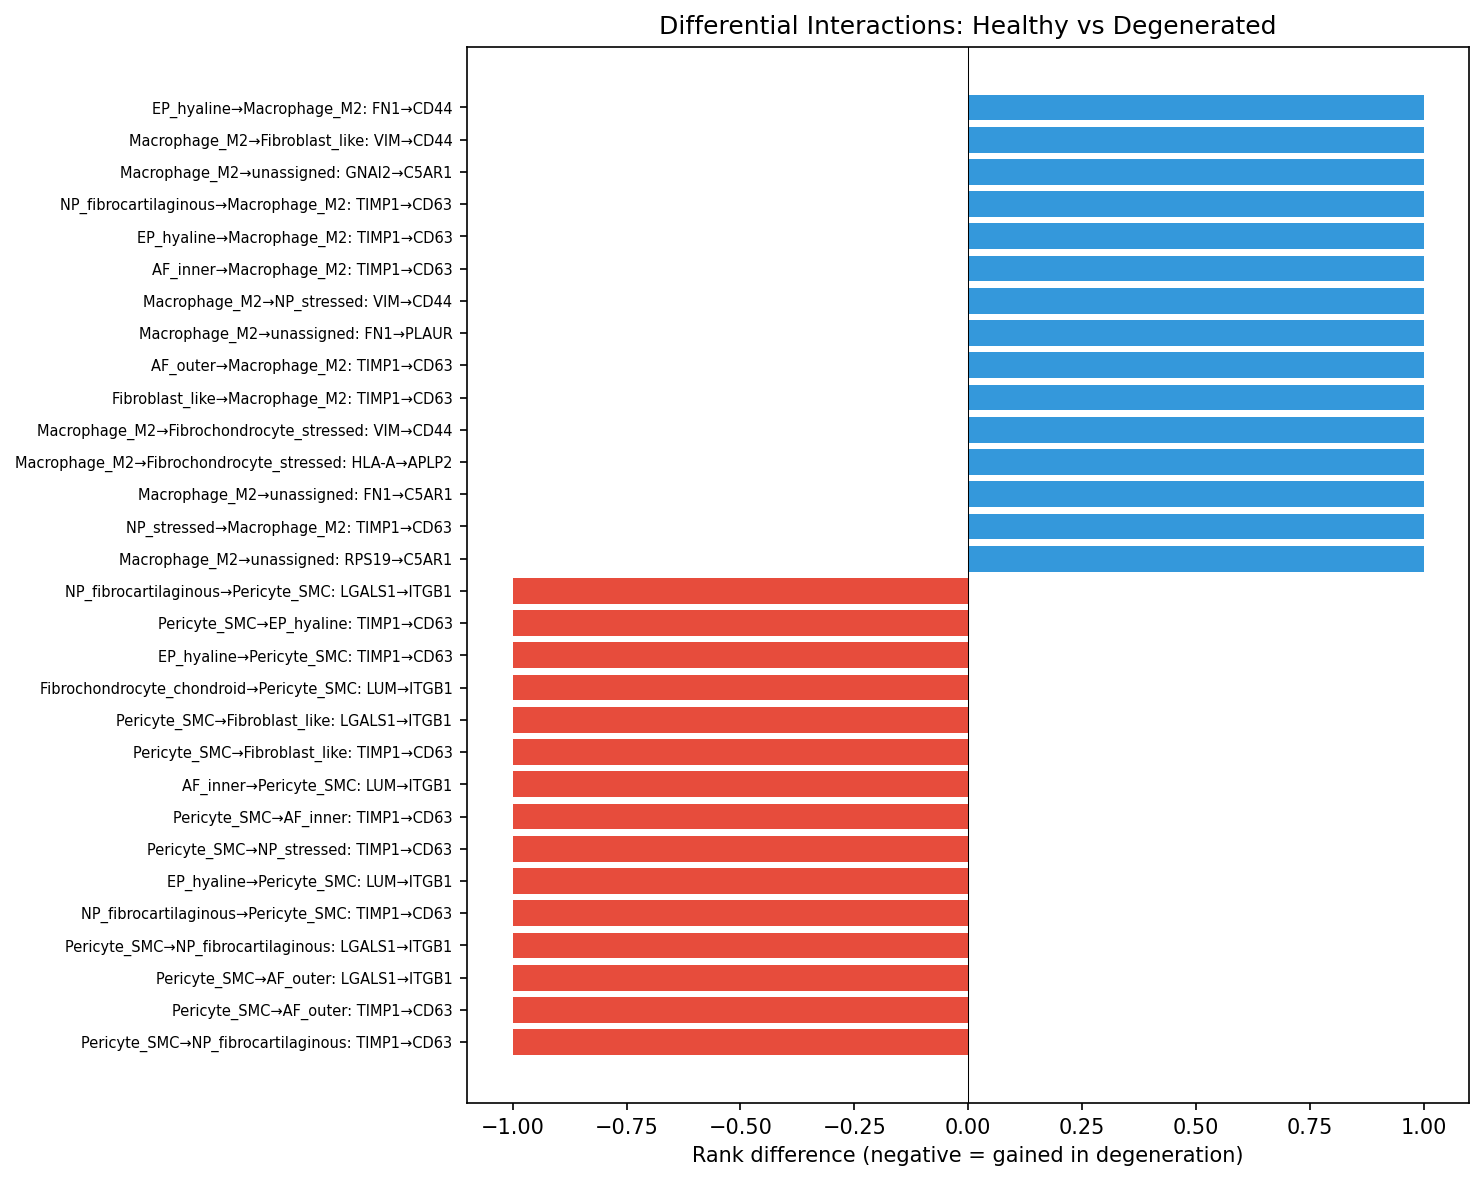

In [7]:
# Differential interactions plot
diff_plot = PLOT_DIR / 'differential_interactions.png'
if diff_plot.exists():
    display(Markdown('### Differential Interactions Plot'))
    display(Image(filename=str(diff_plot), width=800))
else:
    print('Differential interactions plot not found')

## Pain-Relevant Interactions

Ligand-receptor interactions involving pain-related molecules (nociceptive
signaling, inflammatory mediators, neurotrophins). These interactions are
particularly relevant for understanding discogenic pain.

In [8]:
# Pain-relevant interactions
pain_path = RESULTS / 'pain_interactions.tsv'
if pain_path.exists():
    pain = pd.read_csv(pain_path, sep='\t')
    print(f'Total pain-relevant interactions: {len(pain)}')
    
    if 'condition' in pain.columns:
        for cond in pain['condition'].unique():
            n = len(pain[pain['condition'] == cond])
            print(f'  {cond}: {n} interactions')
    
    # Show pain interactions grouped by category
    if 'pain_categories' in pain.columns:
        print(f'\nPain categories represented:')
        # Pain categories may contain multiple categories per row
        all_cats = pain['pain_categories'].dropna().str.split(',').explode().str.strip()
        for cat, count in all_cats.value_counts().items():
            print(f'  {cat}: {count}')
    
    cols = [c for c in ['source', 'target', 'ligand_complex', 'receptor_complex',
                        'lr_means', 'lrscore', 'condition', 'pain_categories']
            if c in pain.columns]
    
    # Show degeneration-specific pain interactions
    if 'condition' in pain.columns:
        degen_pain = pain[pain['condition'] == 'degenerated']
        display(Markdown('**Pain-Relevant Interactions in Degenerated Tissue**'))
        display(degen_pain[cols].head(30).style.set_caption(
            'Top Pain-Relevant Interactions (Degenerated)'))
    else:
        display(pain[cols].head(30))
else:
    print('Pain interactions file not found')

Total pain-relevant interactions: 3184
  degenerated: 3184 interactions

Pain categories represented:
  pain_ligand:FGF2: 690
  pain_ligand:VEGFA: 660
  pain_ligand:TNF: 377
  pain_receptor:NRP2: 211
  pain_receptor:IL6R: 208
  pain_receptor:TNFRSF1A: 169
  pain_ligand:VEGFA; pain_receptor:NRP2: 132
  pain_receptor:FLT1: 112
  pain_ligand:PTGS2: 110
  pain_ligand:SEMA3A; pain_receptor:NRP2: 99
  pain_ligand:NGF: 99
  pain_ligand:CXCL8: 96
  pain_ligand:ANGPT1: 75
  pain_ligand:VEGFB: 66
  pain_ligand:PDGFA: 60
  pain_ligand:CXCL2: 16
  pain_receptor:ROBO1: 3
  pain_receptor:ROBO2: 1


**Pain-Relevant Interactions in Degenerated Tissue**

,source,target,ligand_complex,receptor_complex,lr_means,lrscore,condition,pain_categories
0,unassigned,AF_inner,CXCL8,SDC2,2.243599,0.883363,degenerated,pain_ligand:CXCL8
1,unassigned,NP_mature_chondrocyte,CXCL8,SDC2,2.168553,0.877766,degenerated,pain_ligand:CXCL8
2,unassigned,Fibrochondrocyte_fibroid,PTGS2,CAV1,2.092207,0.882101,degenerated,pain_ligand:PTGS2
3,unassigned,Macrophage_M2,CXCL8,SDC2,2.160797,0.877138,degenerated,pain_ligand:CXCL8
4,unassigned,NP_stressed,CXCL8,SDC2,2.157564,0.876873,degenerated,pain_ligand:CXCL8
5,Fibrochondrocyte_stressed,AF_inner,CXCL8,SDC2,2.076271,0.877132,degenerated,pain_ligand:CXCL8
6,Fibrochondrocyte_stressed,NP_mature_chondrocyte,CXCL8,SDC2,2.001225,0.871279,degenerated,pain_ligand:CXCL8
7,Fibrochondrocyte_stressed,Macrophage_M2,CXCL8,SDC2,1.993469,0.870623,degenerated,pain_ligand:CXCL8
8,Fibrochondrocyte_stressed,NP_stressed,CXCL8,SDC2,1.990236,0.870347,degenerated,pain_ligand:CXCL8
9,AF_outer,AF_outer,TNFSF9,HLA-DPA1,0.121064,0.299745,degenerated,pain_ligand:TNF


## Status — Module 11 Complete (v4)

### Summary
- LIANA cell-cell communication analysis completed for healthy vs degenerated
- Differential analysis identifies rewired signaling pathways
- Pain-relevant interactions catalogued for clinical interpretation

### Key observations
- Changes in total interaction counts between conditions reflect altered
  signaling in degenerated tissue
- Pain-relevant interactions (e.g., involving CXCL8, PTGS2) are identified
  in degenerated tissue
- Immune cells (macrophages, T cells) show altered interaction profiles with
  disc-resident cells in degeneration

### Pipeline complete
This is the final analysis module (Module 11) of the v4 pipeline. All 12
modules have been executed:
01-Dataset Discovery, 02-Metadata, 03-Preprocessing, 04-Classification,
05-Integration, 06-Clustering, 07-Annotation, 08-Differential,
09-Interpretation, 10-Trajectory, 11-Communication, 12-Reporting